In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.impute import SimpleImputer
from sklearn import metrics


In [14]:
#loading dataset from csv to panda dataframe
cars = pd.read_csv('cars.csv')

In [15]:
# Dataset Overview
print(f"Total cars: {len(cars)}")
print(f"Total brands: {cars['Make'].nunique()}")
print(f"Shape: {cars.shape}")


Total cars: 1276
Total brands: 39
Shape: (1276, 141)


In [16]:
# Encode categorical columns
encodings = {
    'Fuel_Type': {'Petrol': 0, 'Diesel': 1, 'CNG': 2},
    'Seller_Type': {'Dealer': 0, 'Individual': 1},
    'Transmission': {'Manual': 0, 'Automatic': 1}
}
for col, mapping in encodings.items():
    cars.replace({col: mapping}, inplace=True)


In [17]:
# Data Cleaning
cars = cars.drop(['Unnamed: 0'], axis=1)
cars = cars.dropna(subset=['Ex-Showroom_Price'])
cars['Ex-Showroom_Price'] = cars['Ex-Showroom_Price'].astype(str).str.replace('Rs. ', '').str.replace(',', '').astype(float)

numeric_cols = [col for col in cars.select_dtypes(include=['float64', 'int64']).columns if col != 'Ex-Showroom_Price']
imputer = SimpleImputer(strategy='mean')
cars[numeric_cols] = imputer.fit_transform(cars[numeric_cols])

cars_clean = cars.copy()
print(f"Data cleaned: {len(cars_clean)} rows, {len(numeric_cols)} features")


Data cleaned: 1276 rows, 6 features


In [18]:
# Split data into features and target
X = cars_clean[numeric_cols]
Y = cars_clean['Ex-Showroom_Price']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=2)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")


Training set: 1148 samples, Test set: 128 samples


In [19]:
# Train Linear Regression Model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
# Evaluate Linear Regression
train_pred = lin_reg_model.predict(X_train)
test_pred = lin_reg_model.predict(X_test)
print(f"Linear Regression - Train R²: {metrics.r2_score(Y_train, train_pred):.4f}, Test R²: {metrics.r2_score(Y_test, test_pred):.4f}")


Linear Regression - Train R²: 0.7052, Test R²: 0.6079


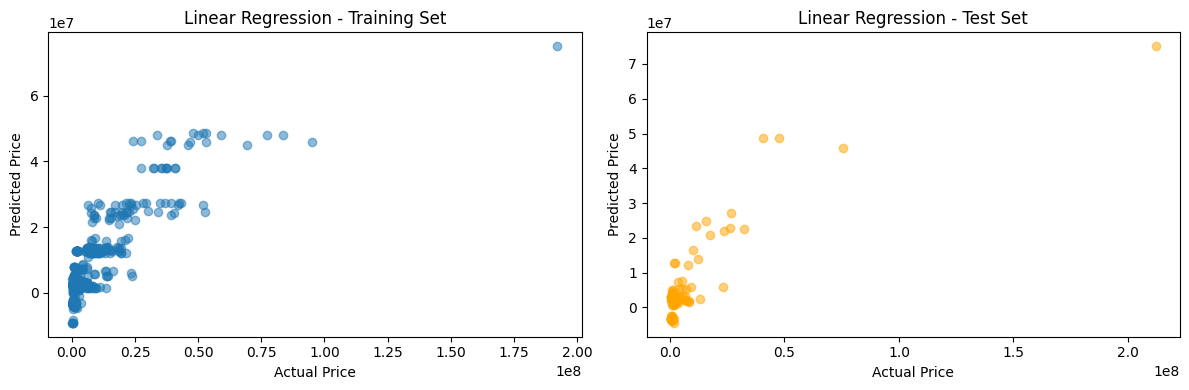

In [21]:
# Plot Linear Regression Results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(Y_train, train_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression - Training Set")

plt.subplot(1, 2, 2)
plt.scatter(Y_test, test_pred, alpha=0.5, color='orange')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression - Test Set")
plt.tight_layout()
plt.show()


In [22]:
# Train Lasso Regression Model
lasso_model = Lasso()
lasso_model.fit(X_train, Y_train)


,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [23]:
# Evaluate Lasso Regression
lasso_train_pred = lasso_model.predict(X_train)
lasso_test_pred = lasso_model.predict(X_test)
print(f"Lasso Regression - Train R²: {metrics.r2_score(Y_train, lasso_train_pred):.4f}, Test R²: {metrics.r2_score(Y_test, lasso_test_pred):.4f}")


Lasso Regression - Train R²: 0.7052, Test R²: 0.6079


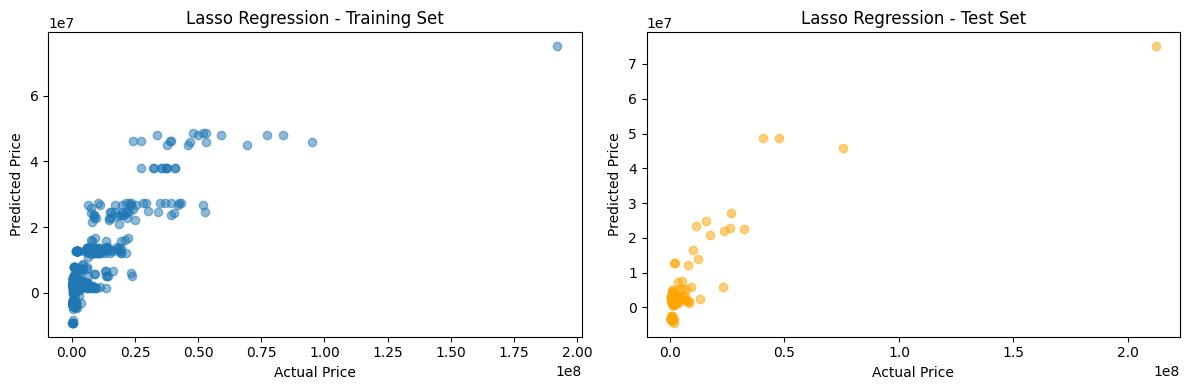

In [24]:
# Plot Lasso Regression Results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(Y_train, lasso_train_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression - Training Set")

plt.subplot(1, 2, 2)
plt.scatter(Y_test, lasso_test_pred, alpha=0.5, color='orange')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression - Test Set")
plt.tight_layout()
plt.show()


Average Price by Body Type:
Body_Type
Sports                 1.407328e+08
Coupe, Convertible     4.336750e+07
Coupe                  2.871417e+07
Convertible            2.502037e+07
Sedan, Coupe           1.226700e+07
Sports, Convertible    7.190000e+06
Sedan, Crossover       4.426500e+06
Sports, Hatchback      4.350000e+06
SUV                    4.255617e+06
SUV, Crossover         4.250000e+06
Sedan                  3.892962e+06
Crossover, SUV         3.675000e+06
MUV                    1.860143e+06
Pick-up                1.820199e+06
MPV                    1.316294e+06
Crossover              8.148526e+05
Hatchback              7.549352e+05
Name: Ex-Showroom_Price, dtype: float64


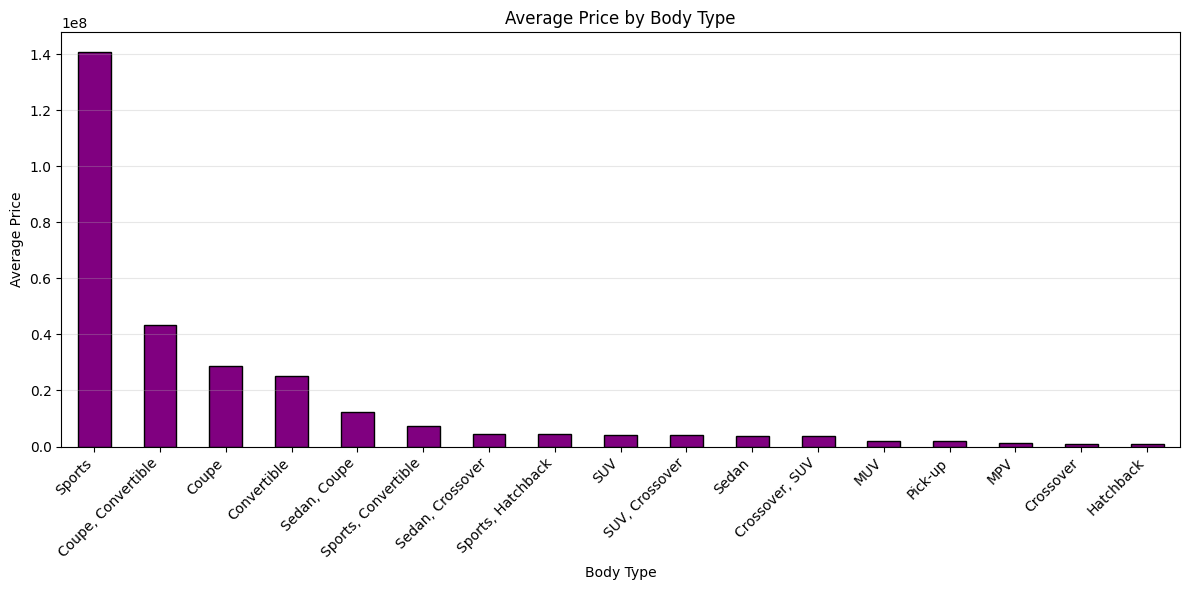

In [25]:
# Average Price by Body Type (since Year is not available in the dataset)
avg_price_by_body = cars_clean.groupby('Body_Type')['Ex-Showroom_Price'].mean().sort_values(ascending=False)
print("Average Price by Body Type:")
print(avg_price_by_body)

plt.figure(figsize=(12, 6))
avg_price_by_body.plot(kind='bar', color='purple', edgecolor='black')
plt.xlabel('Body Type')
plt.ylabel('Average Price')
plt.title('Average Price by Body Type')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Average Price by Brand (Top 15):
Make
Bugatti             2.021492e+08
Ferrari             4.287250e+07
Bentley             4.056585e+07
Lamborghini         3.905392e+07
Aston Martin        3.626744e+07
Land Rover Rover    1.645647e+07
Maserati            1.569689e+07
Porsche             1.534600e+07
Lexus               1.501530e+07
Jaguar              1.046450e+07
Land Rover          8.457080e+06
Bmw                 8.256216e+06
Audi                7.240431e+06
Volvo               5.834750e+06
Mini                3.792000e+06
Name: Ex-Showroom_Price, dtype: float64


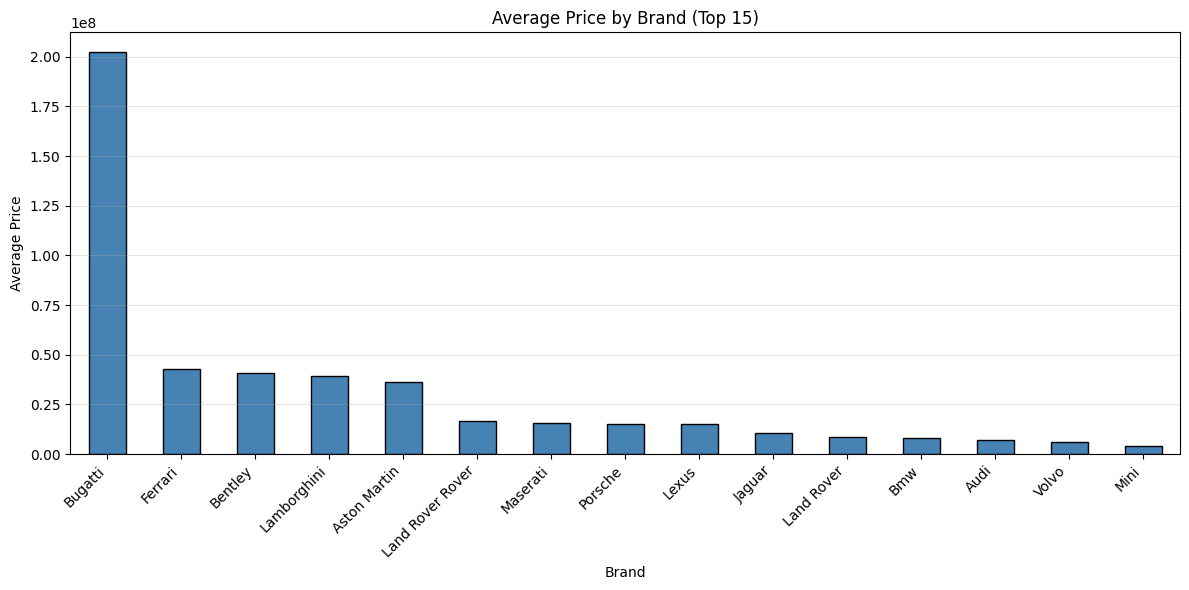

In [26]:
# Average Price by Brand
avg_price_by_brand = cars_clean.groupby('Make')['Ex-Showroom_Price'].mean().sort_values(ascending=False).head(15)
print("Average Price by Brand (Top 15):")
print(avg_price_by_brand)

plt.figure(figsize=(12, 6))
avg_price_by_brand.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.title('Average Price by Brand (Top 15)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Top 10 Cheapest Cars:
         Make       Model       Variant  Ex-Showroom_Price
         Tata   Nano Genx            Xe           236447.0
        Bajaj Qute (Re60)          Qcar           263000.0
         Tata   Nano Genx            Xm           272223.0
       Datsun     Redi-Go             D           279650.0
Maruti Suzuki        Omni   5 Str Bs-Iv           282778.0
        Bajaj Qute (Re60)      Qcar Cng           283000.0
      Renault        Kwid       Std 0.8           283290.0
Maruti Suzuki        Omni E 8 Str Bs-Iv           284485.0
         Tata   Nano Genx            Xt           292667.0
Maruti Suzuki        Alto           Std           294800.0


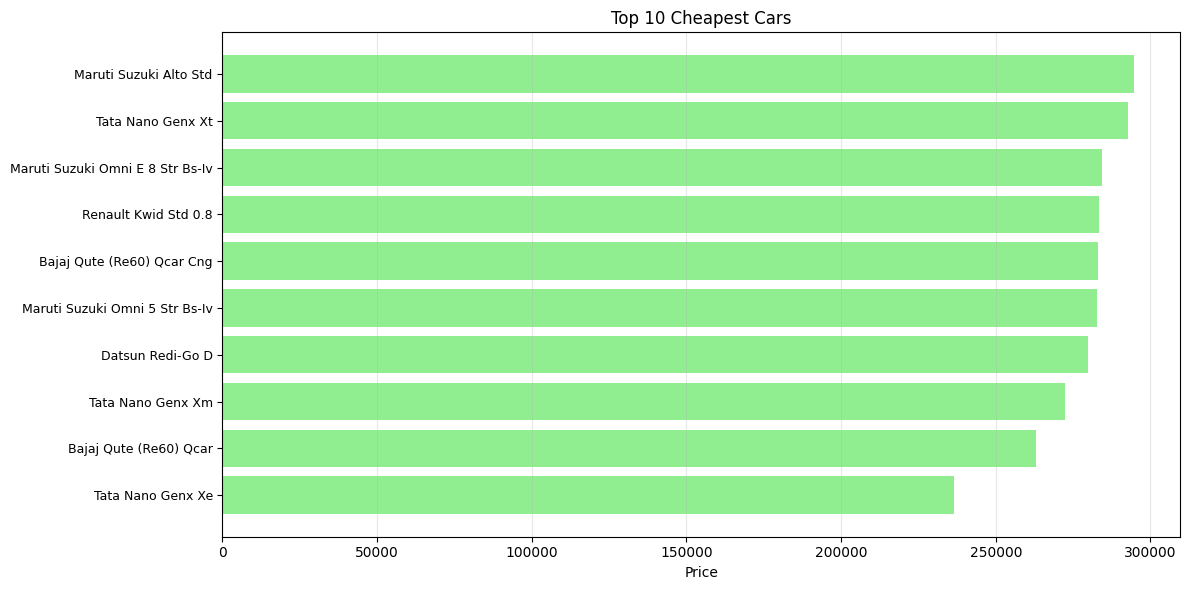

In [27]:
# Top 10 Cheapest Cars
top_10_cheapest = cars_clean.nsmallest(10, 'Ex-Showroom_Price')[['Make', 'Model', 'Variant', 'Ex-Showroom_Price']]
print("Top 10 Cheapest Cars:")
print(top_10_cheapest.to_string(index=False))

plt.figure(figsize=(12, 6))
car_names = (top_10_cheapest['Make'] + ' ' + top_10_cheapest['Model'] + ' ' + top_10_cheapest['Variant']).values
plt.barh(range(len(car_names)), top_10_cheapest['Ex-Showroom_Price'].values, color='lightgreen')
plt.yticks(range(len(car_names)), car_names, fontsize=9)
plt.xlabel('Price')
plt.title('Top 10 Cheapest Cars')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Top 10 Most Expensive Cars:
       Make                       Model          Variant  Ex-Showroom_Price
    Bugatti                      Chiron            Sport        212155397.0
    Bugatti                      Chiron              W16        192142937.0
        NaN         Rolls-Royce Phantom            Sedan         95000000.0
        NaN  Rolls-Royce Drophead Coupe          Phantom         83755383.0
        NaN   Rolls-Royce Phantom Coupe            6.8 L         77312661.0
        NaN         Rolls-Royce Phantom              Ewb         75400000.0
        NaN        Rolls-Royce Cullinan              Suv         69500000.0
        NaN            Rolls-Royce Dawn      Convertible         59216193.0
        NaN Rolls-Royce Ghost Series Ii              Ewb         53247201.0
Lamborghini                   Aventador Lp700-4 Roadster         53210327.0


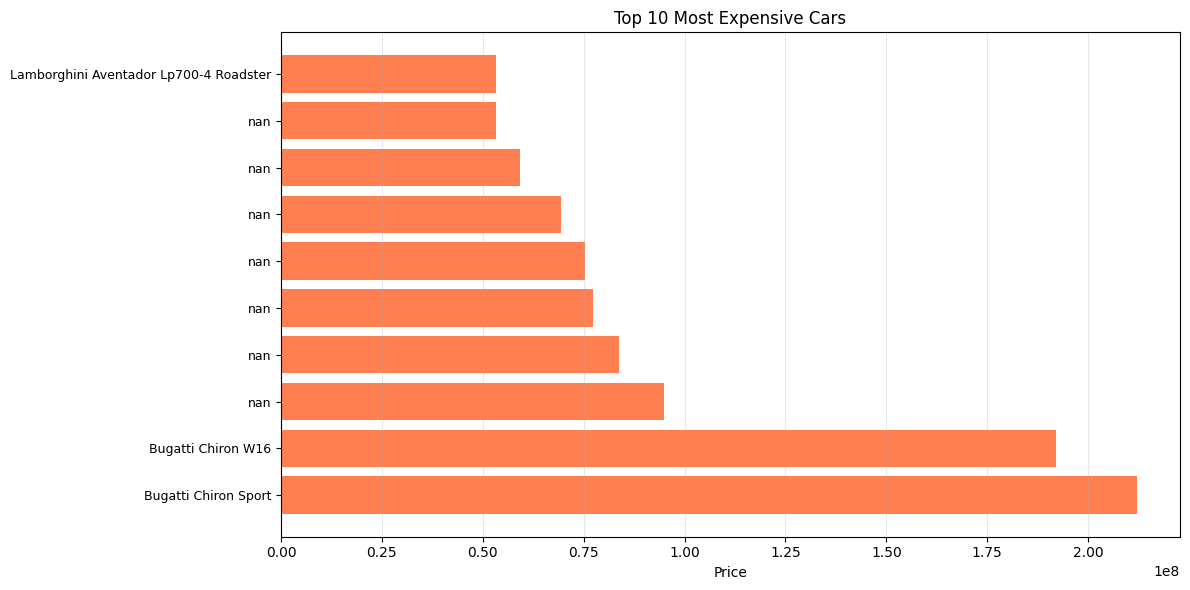

In [28]:
# Top 10 Most Expensive Cars
top_10_expensive = cars_clean.nlargest(10, 'Ex-Showroom_Price')[['Make', 'Model', 'Variant', 'Ex-Showroom_Price']]
print("Top 10 Most Expensive Cars:")
print(top_10_expensive.to_string(index=False))

plt.figure(figsize=(12, 6))
car_names = (top_10_expensive['Make'] + ' ' + top_10_expensive['Model'] + ' ' + top_10_expensive['Variant']).values
plt.barh(range(len(car_names)), top_10_expensive['Ex-Showroom_Price'].values, color='coral')
plt.yticks(range(len(car_names)), car_names, fontsize=9)
plt.xlabel('Price')
plt.title('Top 10 Most Expensive Cars')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


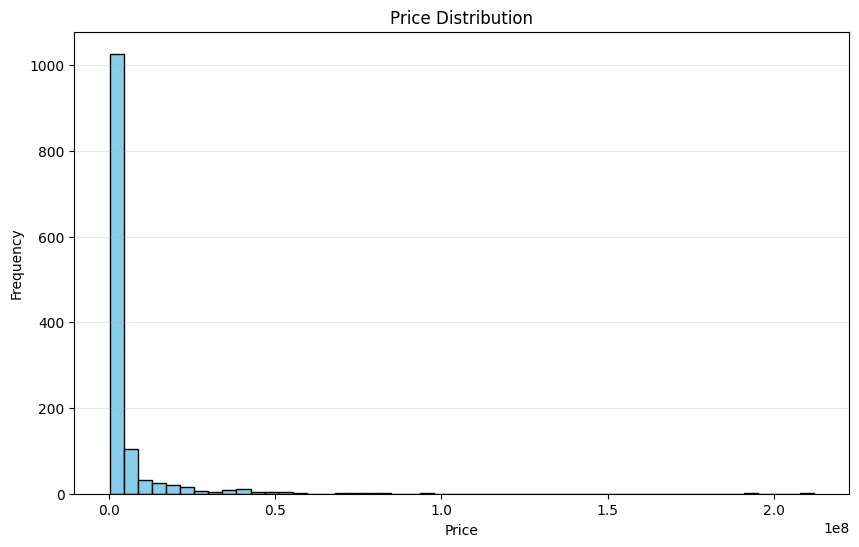

In [29]:
# Price Distribution (Histogram)
plt.figure(figsize=(10, 6))
plt.hist(cars_clean['Ex-Showroom_Price'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.grid(axis='y', alpha=0.3)
plt.show()
